In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r'C:\Users\HP\Desktop\Fund_Data_Analysis\titanic\Titanic-Dataset.csv')

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.shape

(891, 12)

In [5]:
for col in data.columns:
  print(col)

PassengerId
Survived
Pclass
Name
Sex
Age
SibSp
Parch
Ticket
Fare
Cabin
Embarked


In [6]:
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [7]:
data.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    str    
 8   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 68.7 KB


In [9]:
data.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [10]:
(data.isnull().sum()/data.shape[0]).round(2)

Survived    0.00
Pclass      0.00
Sex         0.00
Age         0.20
SibSp       0.00
Parch       0.00
Fare        0.00
Cabin       0.77
Embarked    0.00
dtype: float64

In [11]:
text_columns = data.select_dtypes(include=['object']).columns.tolist()
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

columns_to_move = ['Survived','Pclass']

for col in columns_to_move:
    if col in numeric_columns:
        numeric_columns.remove(col)
    if col not in text_columns:
        text_columns.append(col)

print("Text Columns:", text_columns)
print("Numeric Columns:", numeric_columns)

Text Columns: ['Sex', 'Cabin', 'Embarked', 'Survived', 'Pclass']
Numeric Columns: ['Age', 'SibSp', 'Parch', 'Fare']


C:\Users\HP\AppData\Local\Temp\ipykernel_29572\1444891013.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = data.select_dtypes(include=['object']).columns.tolist()


# Análisis univariante


## Variables categóricas


--- Análisis para la columna: Sex ---
Número de categorías únicas: 2
Conteo de valores:


Sex
male      577
female    314
Name: count, dtype: int64


Distribución de valores (normalizada):


Sex
male      0.648
female    0.352
Name: proportion, dtype: float64

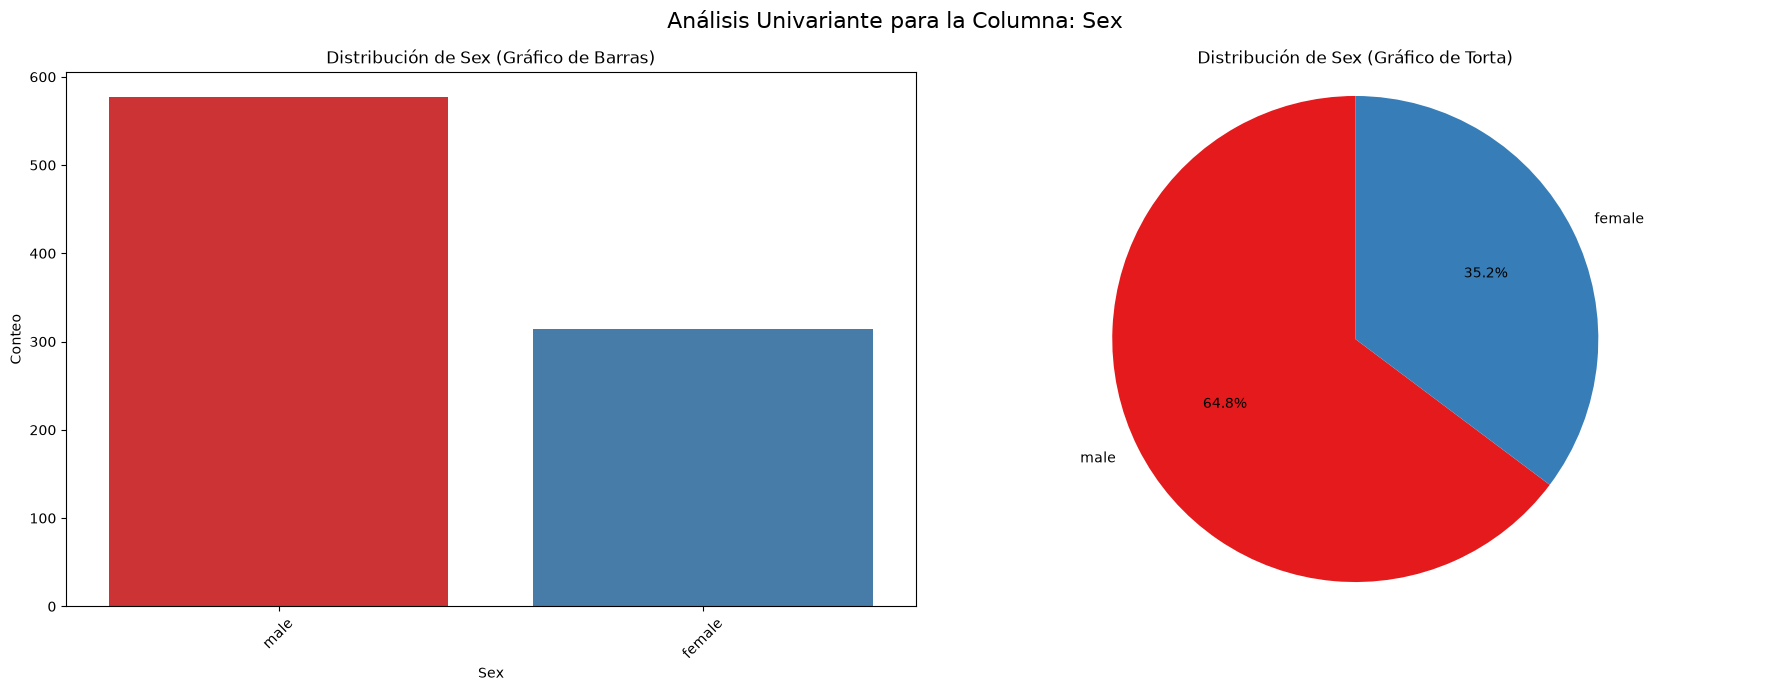


--- Análisis para la columna: Cabin ---
Número de categorías únicas: 148
Conteo de valores:


Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64


Distribución de valores (normalizada):


Cabin
G6             0.020
C23 C25 C27    0.020
B96 B98        0.020
F33            0.015
E101           0.015
               ...  
E17            0.005
A24            0.005
C50            0.005
B42            0.005
C148           0.005
Name: proportion, Length: 147, dtype: float64


--- Análisis para la columna: Embarked ---
Número de categorías únicas: 4
Conteo de valores:


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


Distribución de valores (normalizada):


Embarked
S    0.724
C    0.189
Q    0.087
Name: proportion, dtype: float64

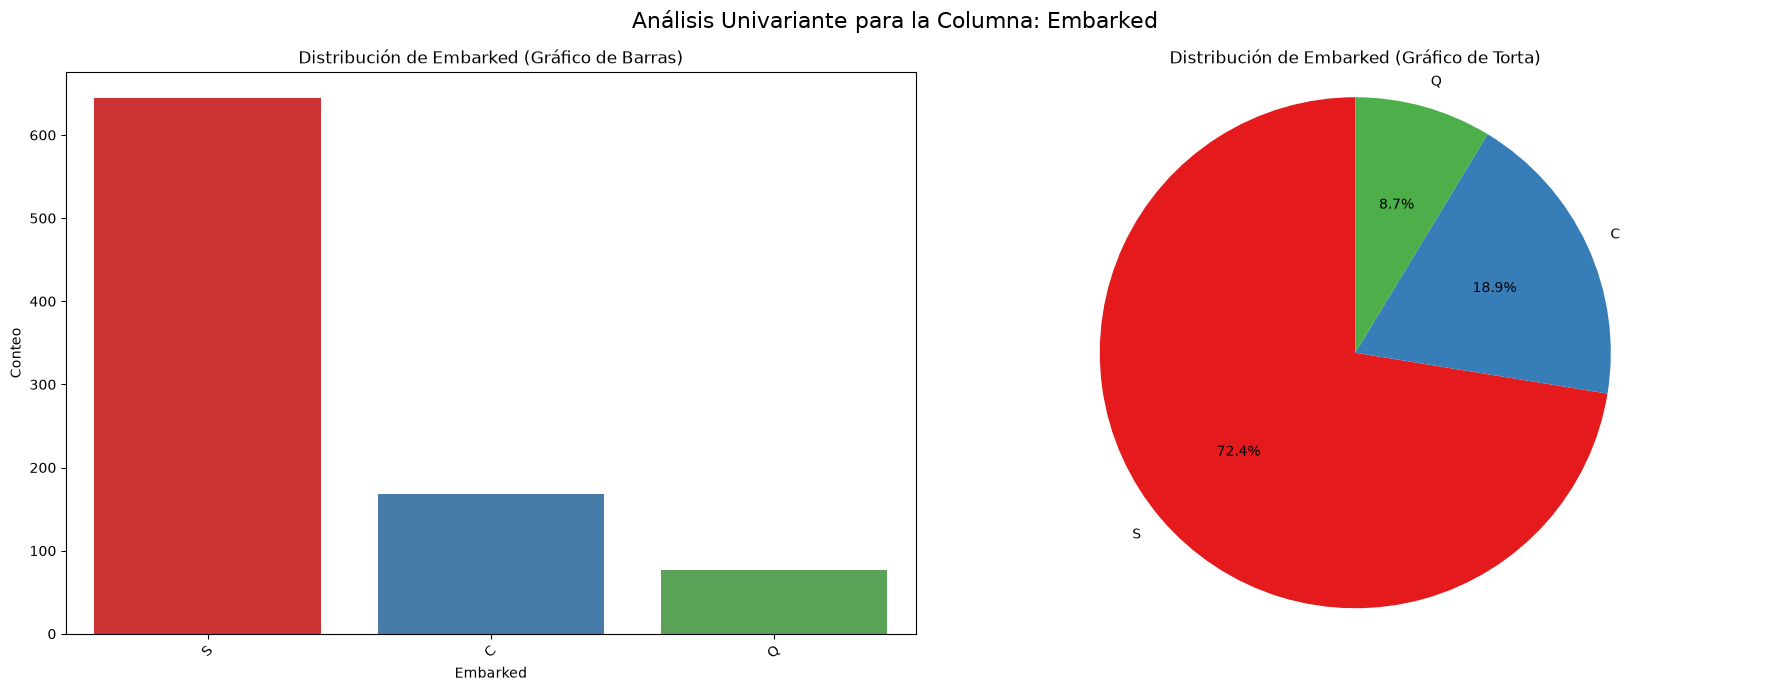


--- Análisis para la columna: Survived ---
Número de categorías únicas: 2
Conteo de valores:


Survived
0    549
1    342
Name: count, dtype: int64


Distribución de valores (normalizada):


Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

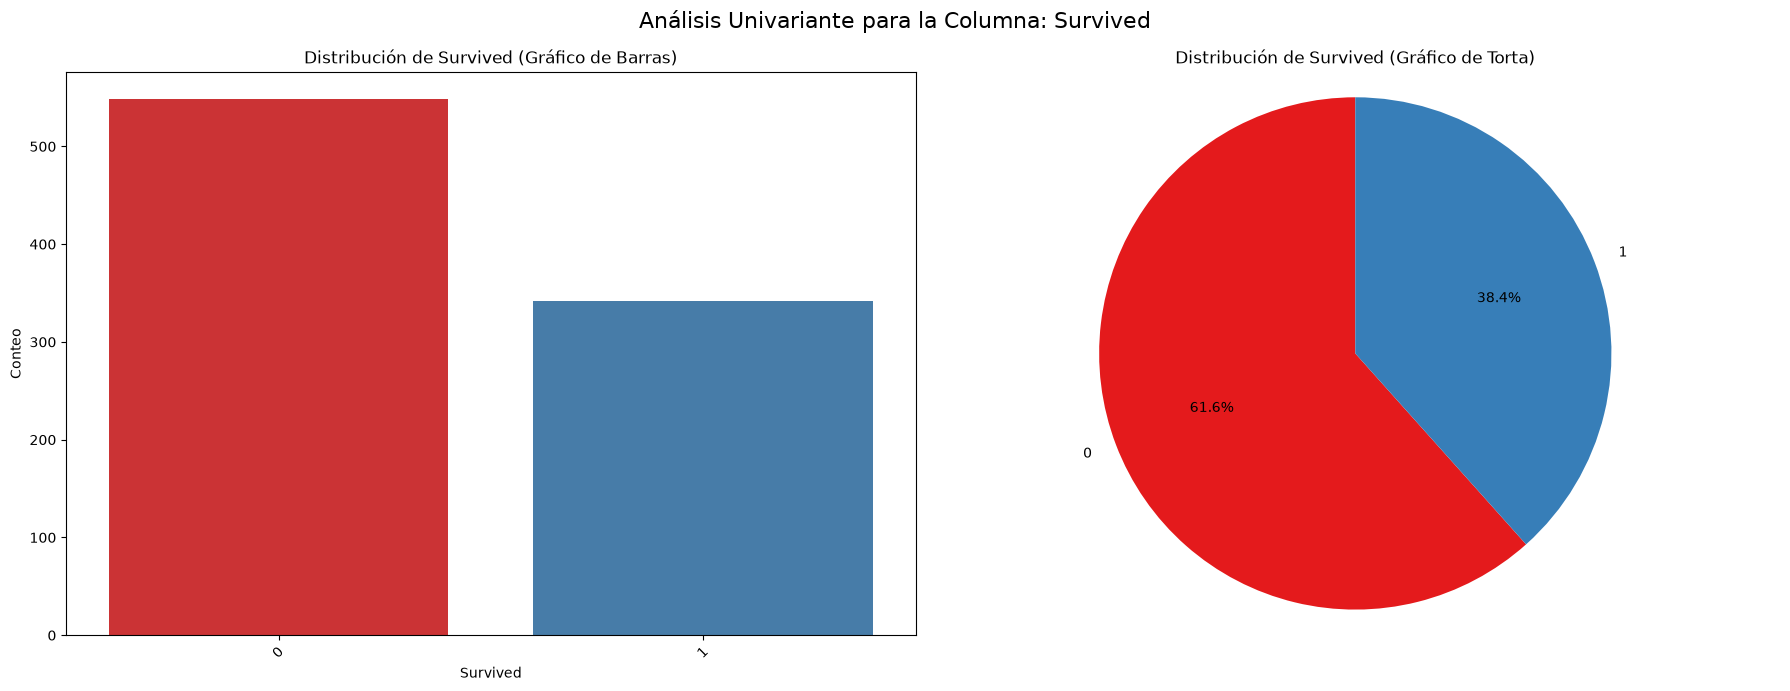


--- Análisis para la columna: Pclass ---
Número de categorías únicas: 3
Conteo de valores:


Pclass
3    491
1    216
2    184
Name: count, dtype: int64


Distribución de valores (normalizada):


Pclass
3    0.551
1    0.242
2    0.207
Name: proportion, dtype: float64

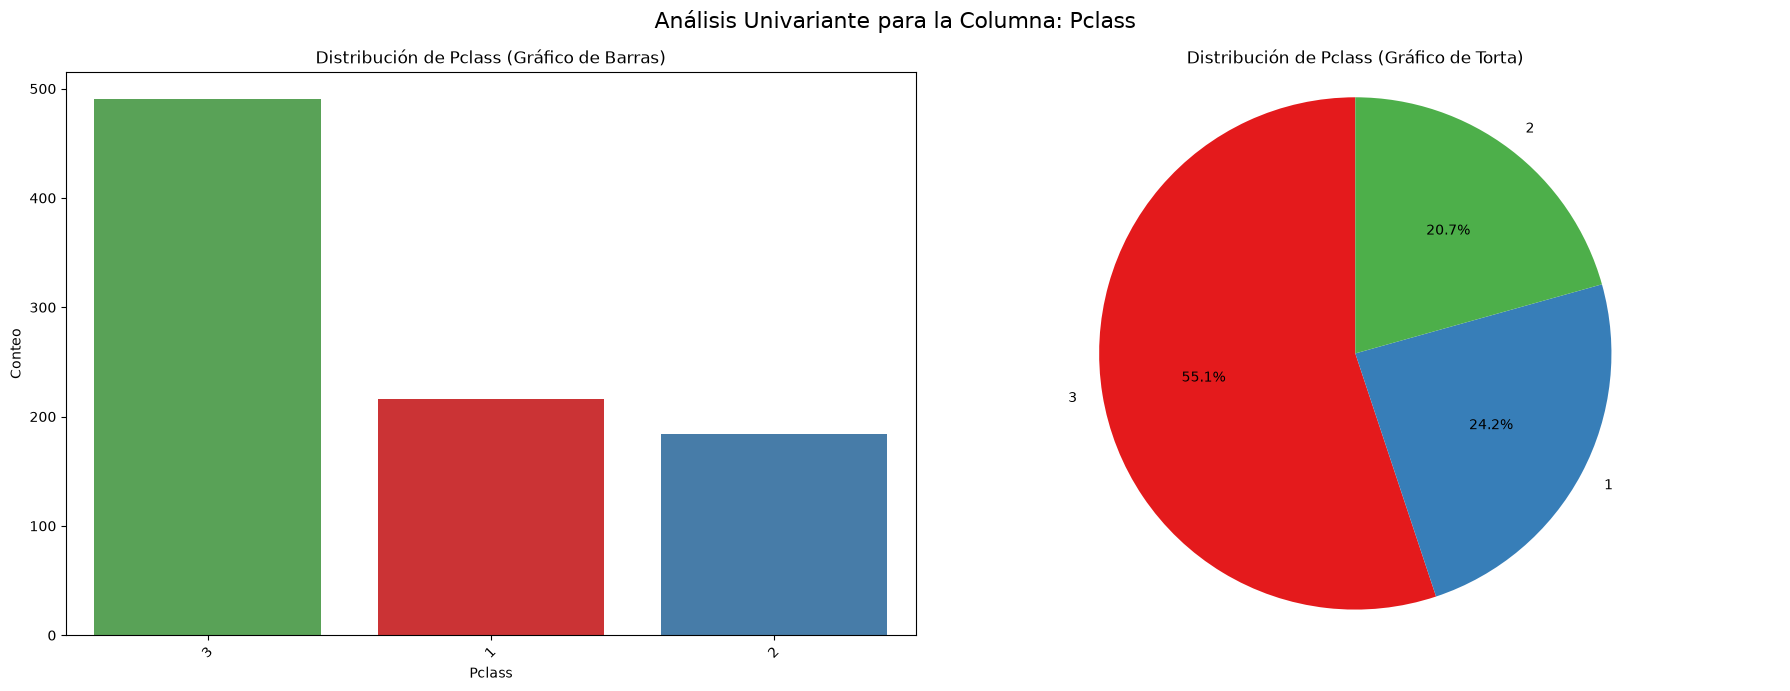

In [12]:
for col in text_columns:
    print(f"\n--- Análisis para la columna: {col} ---")
    print(f"Número de categorías únicas: {len(data[col].unique())}")

    # Display value counts
    print("Conteo de valores:")
    display(data[col].value_counts())
    print("\nDistribución de valores (normalizada):")
    display(data[col].value_counts(normalize=True).round(3))

    if col in ['Cabin']:
      continue
    # Create subplots for bar and pie charts
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Análisis Univariante para la Columna: {col}', fontsize=16)

    # Bar chart
    sns.countplot(data=data, x=col, palette='Set1', ax=axes[0], hue=col, legend=False, order=data[col].value_counts().index)
    axes[0].set_title(f'Distribución de {col} (Gráfico de Barras)')
    axes[0].set_xlabel(col.replace('_', ' ').title())
    axes[0].set_ylabel('Conteo')
    axes[0].tick_params(axis='x', rotation=45)

    # Pie chart
    counts = data[col].value_counts()
    axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set1'))
    axes[1].set_title(f'Distribución de {col} (Gráfico de Torta)')
    axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

    plt.tight_layout()
    plt.show()

## Variables numéricas

In [13]:
data[numeric_columns].describe()

,Age,SibSp,Parch,Fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200



--- Análisis para la columna: Age ---
Estadísticas Descriptivas:


count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

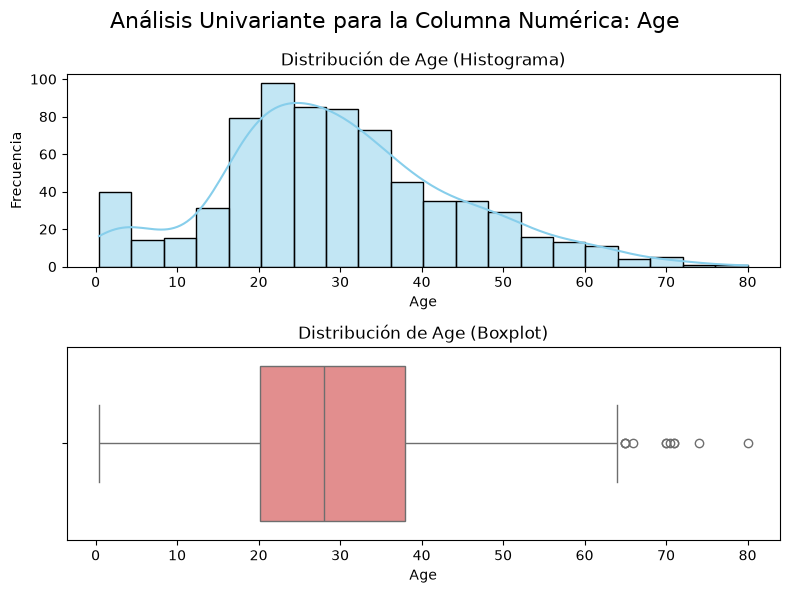


--- Análisis para la columna: SibSp ---
Estadísticas Descriptivas:


count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

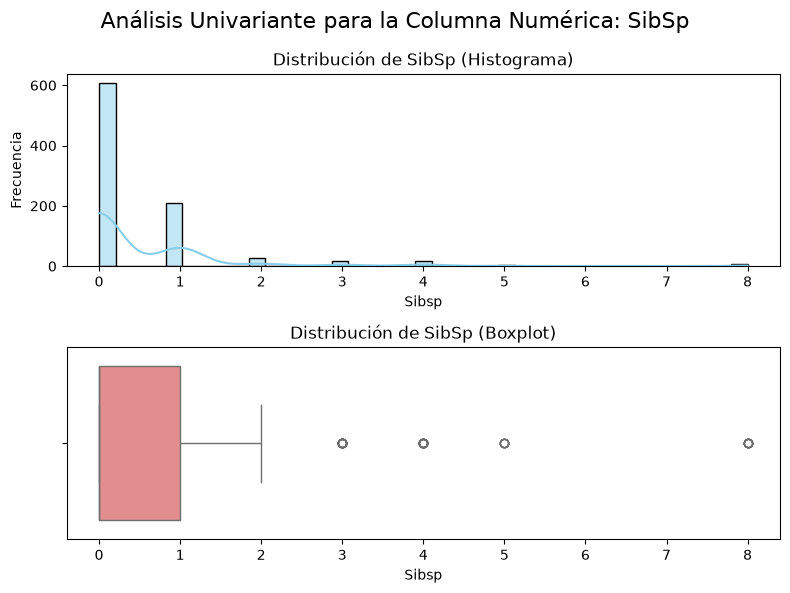


--- Análisis para la columna: Parch ---
Estadísticas Descriptivas:


count    891.000000
mean       0.381594
std        0.806057
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: Parch, dtype: float64

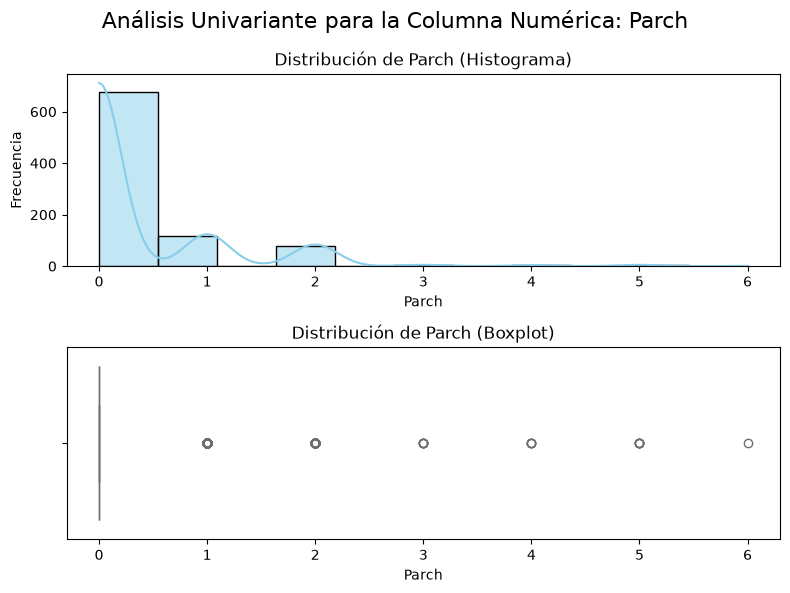


--- Análisis para la columna: Fare ---
Estadísticas Descriptivas:


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

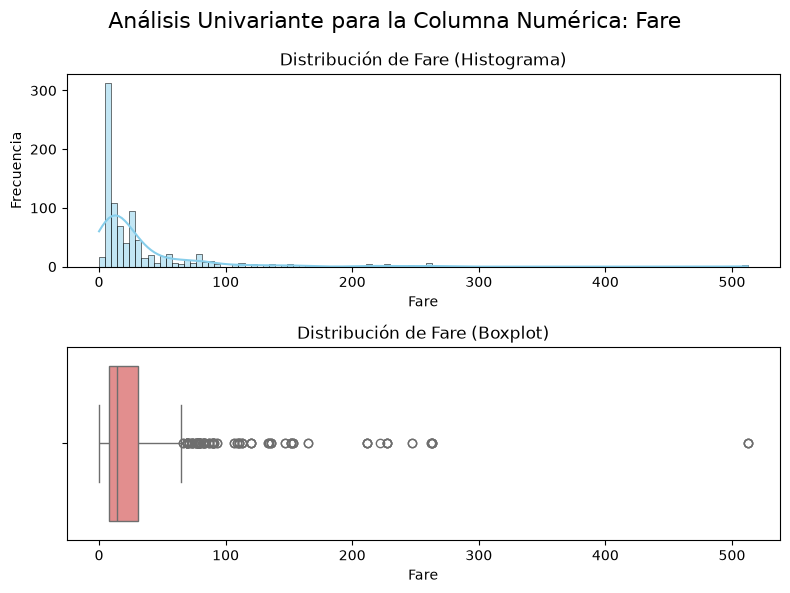

In [14]:
for col in numeric_columns:
    print(f"\n--- Análisis para la columna: {col} ---")
    print("Estadísticas Descriptivas:")
    display(data[col].describe())

    # Create subplots for histogram and boxplot
    fig, axes = plt.subplots(2, 1, figsize=(8, 6)) # 2 rows, 1 column
    fig.suptitle(f'Análisis Univariante para la Columna Numérica: {col}', fontsize=16)

    # Histogram
    sns.histplot(data=data, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribución de {col} (Histograma)')
    axes[0].set_xlabel(col.replace('_', ' ').title())
    axes[0].set_ylabel('Frecuencia')

    # Boxplot
    sns.boxplot(data=data, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Distribución de {col} (Boxplot)')
    axes[1].set_xlabel(col.replace('_', ' ').title())

    plt.tight_layout() # Adjust layout to prevent suptitle overlap
    plt.show()

# Análisis bivariante

## Numérico

In [15]:
data[numeric_columns].corr()

,Age,SibSp,Parch,Fare
Age,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.308247,1.000000,0.414838,0.159651
Parch,-0.189119,0.414838,1.000000,0.216225
Fare,0.096067,0.159651,0.216225,1.000000


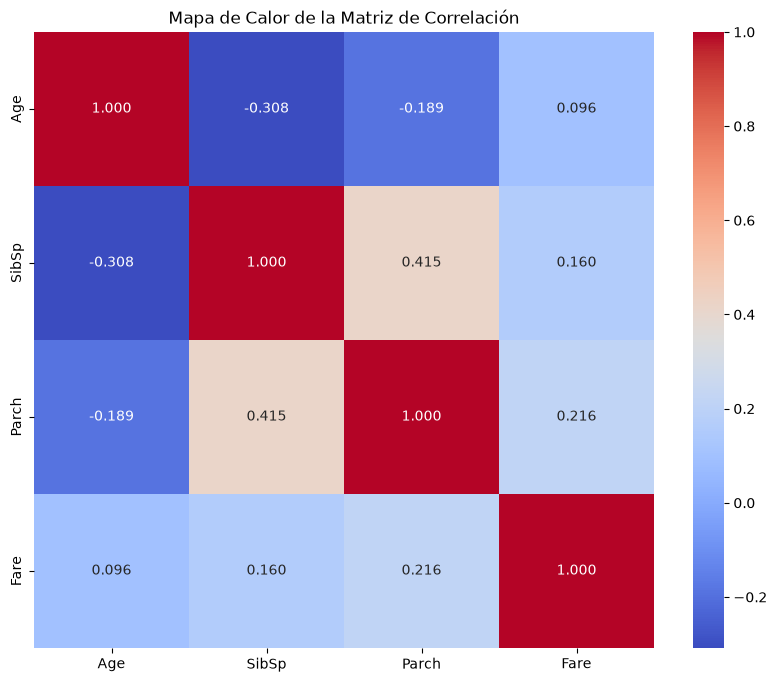

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt=".3f")
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

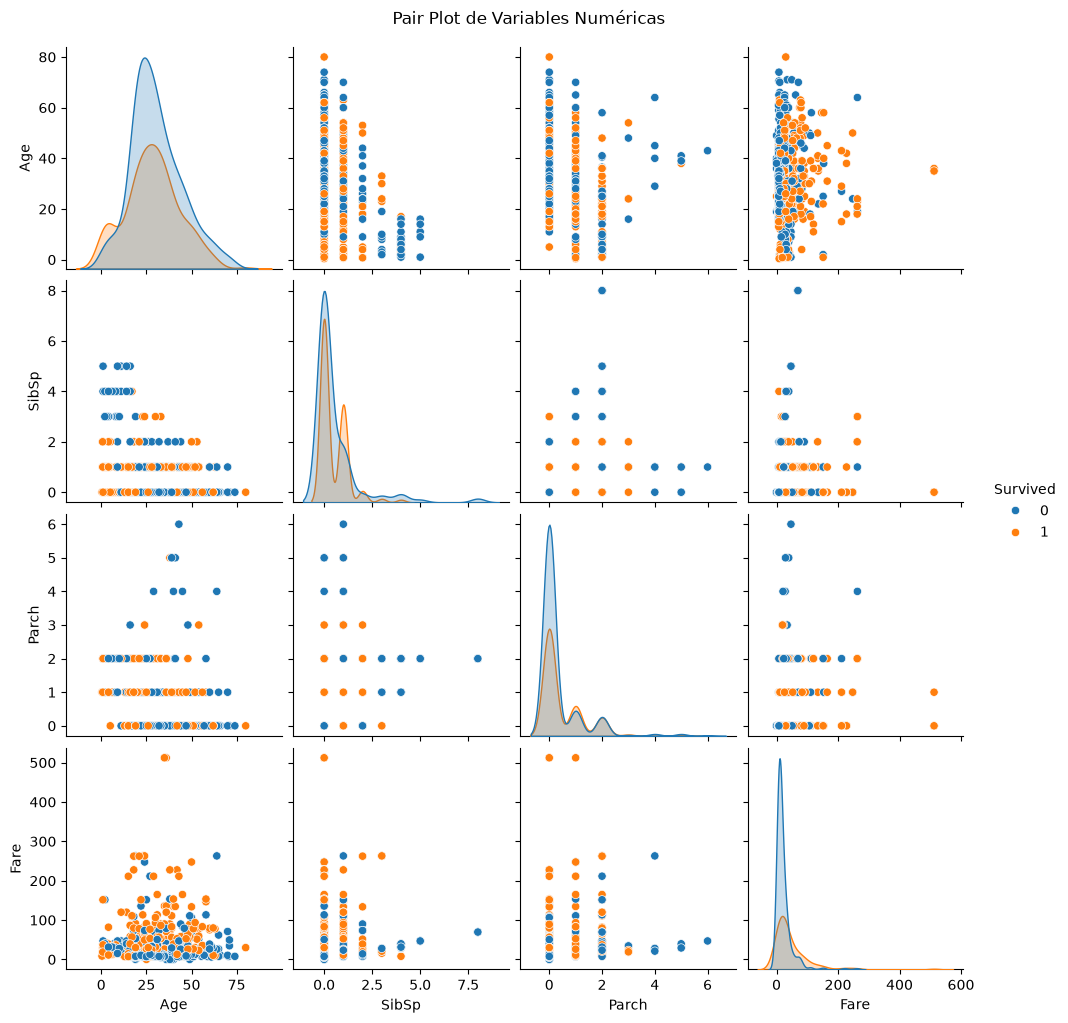

In [17]:
sns.pairplot(data[numeric_columns+['Survived']], hue='Survived')
plt.suptitle('Pair Plot de Variables Numéricas', y=1.02) # Ajusta el título para que no se solape
plt.show()

## Categóricas

In [18]:
text_columns

['Sex', 'Cabin', 'Embarked', 'Survived', 'Pclass']

In [26]:
columna_cat_1 = 'Survived'
columna_cat_2 = 'Pclass'

crosstab_result = pd.crosstab(data[columna_cat_1], data[columna_cat_2])

print(f"Tabla de contingencia entre '{columna_cat_1}' y '{columna_cat_2}':")
display(crosstab_result)

# También puedes ver la distribución normalizada
print(f"\nTabla de contingencia normalizada entre '{columna_cat_1}' y '{columna_cat_2}':")
display(pd.crosstab(data[columna_cat_1], data[columna_cat_2], normalize=True).round(3))

Tabla de contingencia entre 'Survived' y 'Pclass':


Pclass,1,2,3
Survived,,,
0,80,97,372
1,136,87,119



Tabla de contingencia normalizada entre 'Survived' y 'Pclass':


Pclass,1,2,3
Survived,,,
0,0.090,0.109,0.418
1,0.153,0.098,0.134


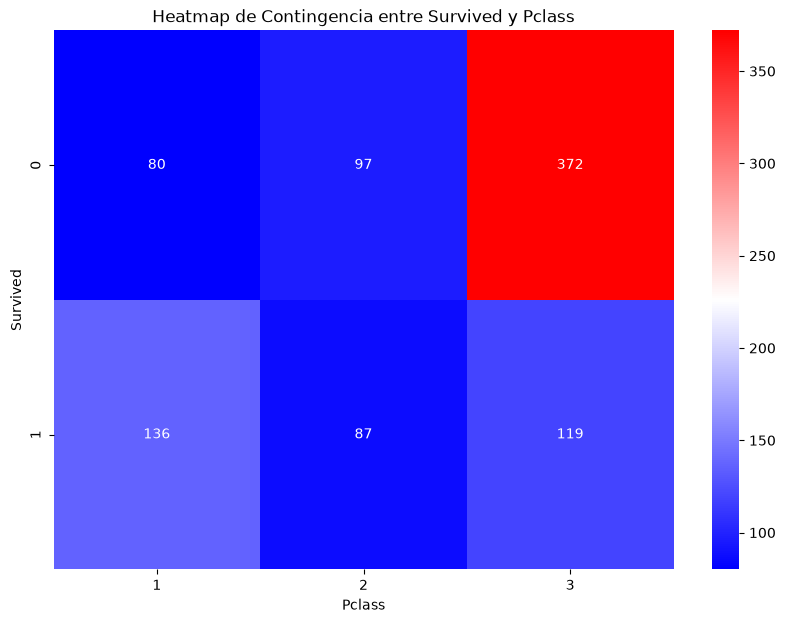

In [27]:
plt.figure(figsize=(10, 7))
sns.heatmap(crosstab_result, annot=True, fmt='d', cmap='bwr')
plt.title(f'Heatmap de Contingencia entre {columna_cat_1.replace("_", " ").title()} y {columna_cat_2.replace("_", " ").title()}')
plt.xlabel(columna_cat_2.replace('_', ' ').title())
plt.ylabel(columna_cat_1.replace('_', ' ').title())
plt.show()

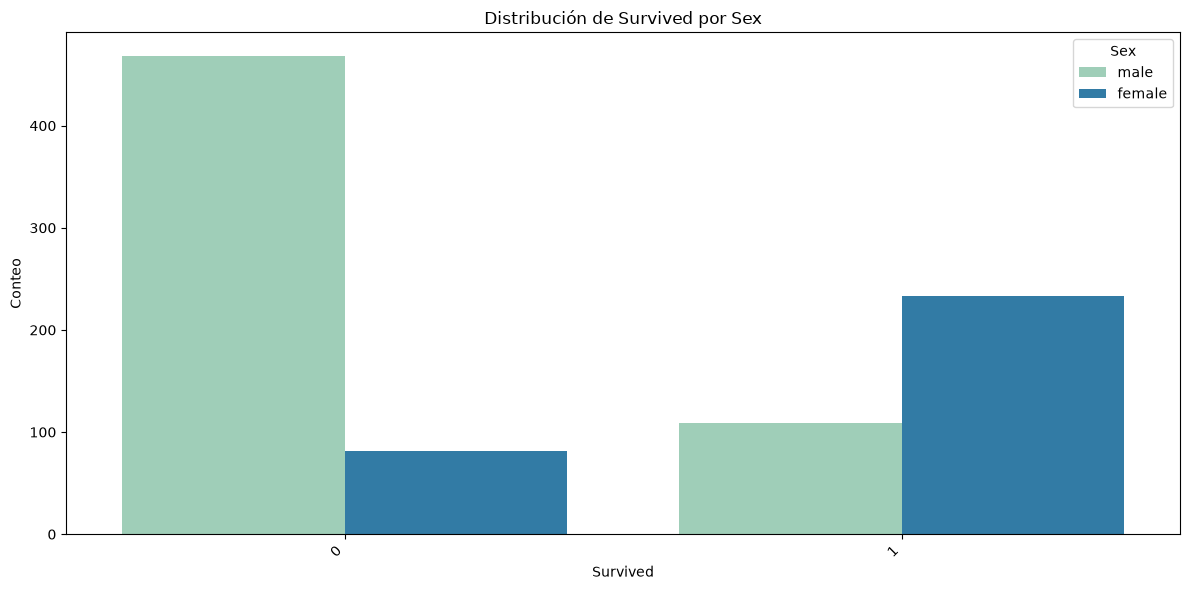

In [29]:
columna_cat_1 = 'Survived'
columna_cat_2 = 'Sex'

plt.figure(figsize=(12, 6))
sns.countplot(data=data, x=columna_cat_1, hue=columna_cat_2, palette='YlGnBu')
plt.title(f'Distribución de {columna_cat_1.replace("_", " ").title()} por {columna_cat_2.replace("_", " ").title()}')
plt.xlabel(columna_cat_1.replace("_", " ").title())
plt.ylabel('Conteo')
plt.xticks(rotation=45, ha='right')
plt.legend(title=columna_cat_2.replace("_", " ").title())
plt.tight_layout()
plt.show()

## Categórico + Numérico

In [30]:
numeric_columns

['Age', 'SibSp', 'Parch', 'Fare']

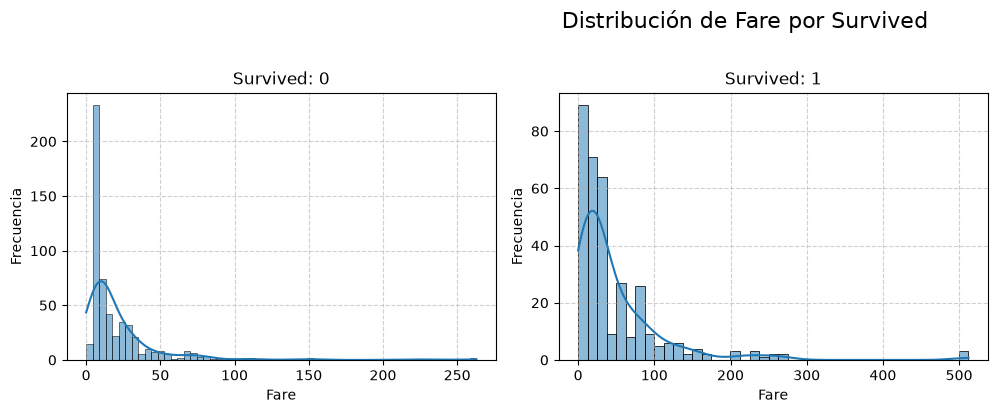

In [32]:
columna_categorica = 'Survived'
columna_numerica = 'Fare'

unique_categories = data[columna_categorica].unique()
num_categories = len(unique_categories)

# Determine grid size for subplots
num_cols = 3 # You can adjust this number
num_rows = (num_categories + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, category in enumerate(unique_categories):
    subset_data = data[data[columna_categorica] == category]
    sns.histplot(data=subset_data, x=columna_numerica, kde=True, ax=axes[i]) # Removed palette argument
    axes[i].set_title(f'{columna_categorica}: {category}')
    axes[i].set_xlabel(f'{columna_numerica}')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Distribución de {columna_numerica.replace("_", " ").title()} por {columna_categorica.replace("_", " ").title()}', fontsize=16, y=1.02)
plt.tight_layout() # Adjust layout to prevent suptitle overlap
plt.show()

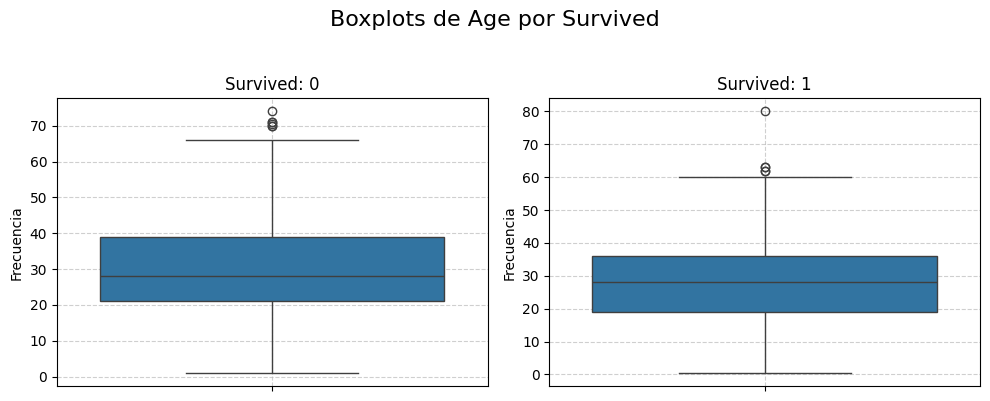

In [35]:
columna_categorica = 'Survived'
columna_numerica = 'Age'

unique_categories = data[columna_categorica].unique()
num_categories = len(unique_categories)

# Determine grid size for subplots
num_cols = 2 # You can adjust this number
num_rows = (num_categories + num_cols - 1) // num_cols
# num_rows = (7 + 3 -1) // 3 = (9) // 3  = 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, category in enumerate(unique_categories):
    subset_data = data[data[columna_categorica] == category]
    sns.boxplot(data=subset_data, y=columna_numerica, ax=axes[i]) # Removed palette argument
    axes[i].set_title(f'{columna_categorica}: {category}')
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlabel('') # Boxplots don't usually need an x-label for single category
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Boxplots de {columna_numerica.replace("_", " ").title()} por {columna_categorica.replace("_", " ").title()}', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()